# Part 1 — Spatial graph topology

**Question.** To what extent is tissue architecture (as captured by the spatial cell graph) a property of the imaging/segmentation pipeline vs. a property of the underlying biology? More concretely: are the topological properties of the per-sample spatial graphs consistent across patients/samples? Where they differ, do the differences track with interpretable biological covariates (cell-type composition, patient identity)?

**Scope.**

- *Free-tier metrics* (degree, clustering coefficient, connected components, assortativity by cell type, PageRank, k-core decomposition) — computed on **all 112 samples**.
- *Expensive-tier metrics* (betweenness, closeness, approximate shortest paths) — computed on a **representative subset of ~10 samples** spanning the size distribution.

**Graph definition.**

- One graph per sample (per DESIGN.md §3.2 — per-sample analysis is the natural unit since edges only exist within samples).
- Headline analysis: **unweighted, undirected**.
- Robustness check: **weighted** by `1 - mean(neighbor_radius)`, undirected.
- Data quirks handled by `src/graph_construction.py`: -1 padding → no edge, 454 cross-sample edges → filtered, KNN asymmetry → symmetrized (union).

## 0. Setup

Imports and global-array loading. Globals are ~600 MB total and stay loaded throughout the notebook.

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# allow importing from src/ regardless of where the notebook was launched
ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").is_dir():           # if running from notebooks/
    sys.path.insert(0, str(ROOT.parent / "src"))

import data_io
import graph_construction
importlib.reload(data_io)                      # in case earlier imports are cached
importlib.reload(graph_construction)

CACHE_DIR = "cache" if (ROOT / "cache").is_dir() else "../cache"

G = data_io.load_global(CACHE_DIR)
print(f"global arrays loaded from {CACHE_DIR}")
print(f"  n_cells:      {G.n_cells:,}")
print(f"  n_patients:   {len(np.unique(G.patient))}")
print(f"  n_samples:    {len(np.unique(G.sample))}")

global arrays loaded from ../cache
  n_cells:      8,065,561
  n_patients:   56
  n_samples:    112


## 0.1 Smoke test: graph construction

Before computing any topology metrics, verify that `graph_construction.build_for_sample` produces a correct graph on a single sample. We use **sample 47** because we visualised its spatial layout in Part 0 (it has recognisable structure — the cyan tumor mass — that we can sanity-check against).

Checks:

1. No self-loops, no out-of-range indices.
2. Every edge appears in both directions (true undirected representation).
3. All node `global_idxs` belong to the requested sample.
4. Isolated nodes count matches what `neighbors_idxs` predicts independently.
5. Spot-check one cell's neighbors against the raw global arrays.
6. igraph adapter produces a graph with the same vertex / edge counts.

In [2]:
import time

sample_id = 47
print(f"building spatial graph for sample {sample_id}...")
t0 = time.time()
sg = graph_construction.build_for_sample(sample_id, global_arrays=G, weighted=False)
print(f"  construction time:  {time.time() - t0:.2f}s")
print(f"  n_nodes:            {sg.n_nodes:,}")
print(f"  n_edges (undirect): {sg.n_edges:,}")
print(f"  edge_index shape:   {sg.edge_index.shape}")
print(f"  edge_weight:        {sg.edge_weight}")
print(f"  global_idxs.shape:  {sg.global_idxs.shape}, "
      f"range=[{sg.global_idxs.min()}, {sg.global_idxs.max()}]")

building spatial graph for sample 47...
  construction time:  0.11s
  n_nodes:            50,988
  n_edges (undirect): 174,939
  edge_index shape:   (2, 349878)
  edge_weight:        None
  global_idxs.shape:  (50988,), range=[6424995, 6494002]


In [3]:
# --- 1, 2: structural integrity ---
src, dst = sg.edge_index
print("--- structural integrity ---")
print(f"any self-loops?               {(src == dst).any()}")
print(f"any out-of-range src?         {(src < 0).any() or (src >= sg.n_nodes).any()}")
print(f"any out-of-range dst?         {(dst < 0).any() or (dst >= sg.n_nodes).any()}")

# Both-directions check via set equality
fwd = set(zip(src.tolist(), dst.tolist()))
rev = set(zip(dst.tolist(), src.tolist()))
print(f"every edge appears in both directions? {fwd == rev}")

# --- 3: cross-sample leak check ---
assert (G.sample[sg.global_idxs] == sample_id).all(), "cross-sample leak"
print(f"all {sg.n_nodes:,} nodes belong to sample {sample_id}? True")

--- structural integrity ---
any self-loops?               False
any out-of-range src?         False
any out-of-range dst?         False
every edge appears in both directions? True
all 50,988 nodes belong to sample 47? True


In [4]:
# --- 4: isolated-node count matches an independent calculation ---
degree = np.bincount(src, minlength=sg.n_nodes)
print("--- degree distribution ---")
print(f"min: {degree.min()}, median: {int(np.median(degree))}, "
      f"max: {degree.max()}, mean: {degree.mean():.2f}")
n_isolated_from_graph = int((degree == 0).sum())
print(f"isolated (degree-0) nodes from graph:        {n_isolated_from_graph:,}  "
      f"({100*n_isolated_from_graph/sg.n_nodes:.2f}%)")

# Independent calculation: which sample-47 cells are degree-0?
# A node is degree-0 iff (a) all its outgoing slots are -1 or out-of-sample
# AND (b) no other in-sample cell lists it as a neighbor.
sample_nbr = G.neighbors_idxs[sg.global_idxs]               # (n_nodes, 8)

# Build a global -> local map for this sample
gmap = np.full(G.n_cells, -1, dtype=np.int32)
gmap[sg.global_idxs] = np.arange(sg.n_nodes, dtype=np.int32)

# Outgoing: for each node, do any of its 8 slots point to an in-sample cell?
valid = sample_nbr >= 0
nbr_local = gmap[np.where(valid, sample_nbr, 0)]            # (n_nodes, 8)
has_outgoing = ((nbr_local >= 0) & valid).any(axis=1)

# Incoming: which nodes are pointed to by other in-sample cells?
incoming = np.zeros(sg.n_nodes, dtype=bool)
in_sample_targets = nbr_local[(nbr_local >= 0) & valid]
incoming[in_sample_targets] = True

expected_isolated = int((~has_outgoing & ~incoming).sum())
print(f"expected isolated from raw neighbors_idxs:   {expected_isolated:,}")
print(f"  match? {n_isolated_from_graph == expected_isolated}")

--- degree distribution ---
min: 0, median: 8, max: 15, mean: 6.86
isolated (degree-0) nodes from graph:        1,164  (2.28%)
expected isolated from raw neighbors_idxs:   1,164
  match? True


In [5]:
# --- 5: spot-check one specific non-isolated cell ---
local_id = int(np.where(degree > 0)[0][1000])              # pick a cell with neighbors
global_id = int(sg.global_idxs[local_id])

# Neighbors according to our graph
nbrs_local = dst[src == local_id]
nbrs_from_edges_global = set(sg.global_idxs[nbrs_local].tolist())

# Expected from raw data (forward direction: cells this cell lists, in-sample only)
raw_nbrs = G.neighbors_idxs[global_id]
raw_valid = raw_nbrs >= 0
raw_in_sample = (G.sample[np.where(raw_valid, raw_nbrs, 0)] == sample_id) & raw_valid
direct_nbrs = set(raw_nbrs[raw_in_sample].tolist())

# Reverse direction: cells in-sample that list THIS cell anywhere in their 8 slots
who_points_to_us = np.where(
    (G.neighbors_idxs == global_id).any(axis=1) & (G.sample == sample_id)
)[0]
reverse_nbrs = set(int(x) for x in who_points_to_us)

expected = direct_nbrs | reverse_nbrs
print(f"--- spot-check: local node {local_id} (global cell {global_id}) ---")
print(f"  forward neighbors (this cell points to):   {len(direct_nbrs)}")
print(f"  reverse neighbors (others point to this):  {len(reverse_nbrs)}")
print(f"  expected union:                            {len(expected)}")
print(f"  actual from edge_index:                    {len(nbrs_from_edges_global)}")
print(f"  sets match? {expected == nbrs_from_edges_global}")

--- spot-check: local node 1001 (global cell 6425996) ---
  forward neighbors (this cell points to):   8
  reverse neighbors (others point to this):  7
  expected union:                            8
  actual from edge_index:                    8
  sets match? True


In [6]:
# --- 6: igraph adapter ---
t0 = time.time()
ig_graph = graph_construction.to_igraph(sg)
print(f"--- igraph adapter (conversion took {time.time() - t0:.2f}s) ---")
print(f"  vcount:   {ig_graph.vcount():,}  (should match n_nodes: {sg.n_nodes:,})")
print(f"  ecount:   {ig_graph.ecount():,}  (should match n_edges:  {sg.n_edges:,})")
print(f"  directed? {ig_graph.is_directed()}")
print(f"  global_idx vertex attribute present? "
      f"{'global_idx' in ig_graph.vertex_attributes()}")

--- igraph adapter (conversion took 0.63s) ---
  vcount:   50,988  (should match n_nodes: 50,988)
  ecount:   174,939  (should match n_edges:  174,939)
  directed? False
  global_idx vertex attribute present? True


## 1. Free-tier topology metrics

We compute a suite of cheap per-graph summary statistics for every sample. First, smoke-test on sample 47 to confirm the metric values are sensible and the timing is reasonable.

In [7]:
import topology
importlib.reload(topology)

# We already have sg (sample 47, unweighted) from Cell 5.
# Get the cell types for these nodes (aligned with sg.global_idxs):
ct_47 = G.cell_type[sg.global_idxs]
print(f"cell_type vector for sample 47: shape={ct_47.shape}, "
      f"unique={sorted(np.unique(ct_47).tolist())}")
print(f"class distribution in sample 47:")
for c, n in zip(*np.unique(ct_47, return_counts=True)):
    print(f"  class {c}: {n:>6,}  ({100*n/len(ct_47):.1f}%)")

cell_type vector for sample 47: shape=(50988,), unique=[0, 1, 2, 3, 4, 5, 6, 7]
class distribution in sample 47:
  class 0:  3,719  (7.3%)
  class 1:  4,141  (8.1%)
  class 2: 32,940  (64.6%)
  class 3:  8,849  (17.4%)
  class 4:    102  (0.2%)
  class 5:    270  (0.5%)
  class 6:    685  (1.3%)
  class 7:    282  (0.6%)


In [8]:
t0 = time.time()
metrics_47 = topology.compute_free_tier_metrics(sg, cell_type=ct_47)
print(f"free-tier metrics for sample 47 (computed in {time.time() - t0:.2f}s):\n")
for k, v in metrics_47.items():
    if isinstance(v, float):
        print(f"  {k:35s} {v:>12.4f}")
    else:
        print(f"  {k:35s} {v:>12,}")

free-tier metrics for sample 47 (computed in 0.09s):

  sample_id                                     47
  n_nodes                                   50,988
  n_edges                                  174,939
  mean_degree                               6.8620
  median_degree                             8.0000
  max_degree                                    15
  degree_std                                2.8909
  n_isolated                                 1,164
  frac_isolated                             0.0228
  n_components                               2,237
  largest_component_size                    20,020
  largest_component_frac                    0.3926
  n_components_excluding_isolates            1,073
  n_components_ge_100                           29
  frac_in_components_ge_100                 0.8228
  n_components_ge_500                            7
  frac_in_components_ge_500                 0.7250
  transitivity_global                       0.5323
  mean_local_clustering     

## 1.1 Investigating fragmentation

The free-tier metrics showed sample 47 has 2,237 connected components and the largest covers only 39% of cells. This is much more fragmented than a naive KNN graph would be, so the radius threshold must be cutting the tissue into many pieces. Before scaling the analysis to all 112 samples, we want to understand:

1. **Where does the cell mass sit?** A few medium components, or thousands of tiny ones?
2. **Do components map to spatially coherent tissue regions** (i.e. the fragmentation reflects real tissue islands), or are they scattered throughout otherwise-dense tissue (suggesting the threshold is just aggressive)?

sample 47: 2,237 components in 50,988 nodes

bucket                       n_comps    n_cells   %cells
--------------------------------------------------------
size == 1 (isolates)           1,164      1,164    2.28%
size 2-10                        888      3,324    6.52%
size 11-100                      156      4,545    8.91%
size 101-1000                     24      6,461   12.67%
size > 1000                        5     35,494   69.61%

fraction of cells in components of size >= K:
  K =     2:  49,824 cells (97.7%) in 1,073 components
  K =    10:  46,650 cells (91.5%) in 200 components
  K =    50:  43,627 cells (85.6%) in 53 components
  K =   100:  41,955 cells (82.3%) in 29 components
  K =   500:  36,964 cells (72.5%) in 7 components
  K = 1,000:  35,494 cells (69.6%) in 5 components
  K = 5,000:  31,073 cells (60.9%) in 2 components
  K = 10,000:  31,073 cells (60.9%) in 2 components


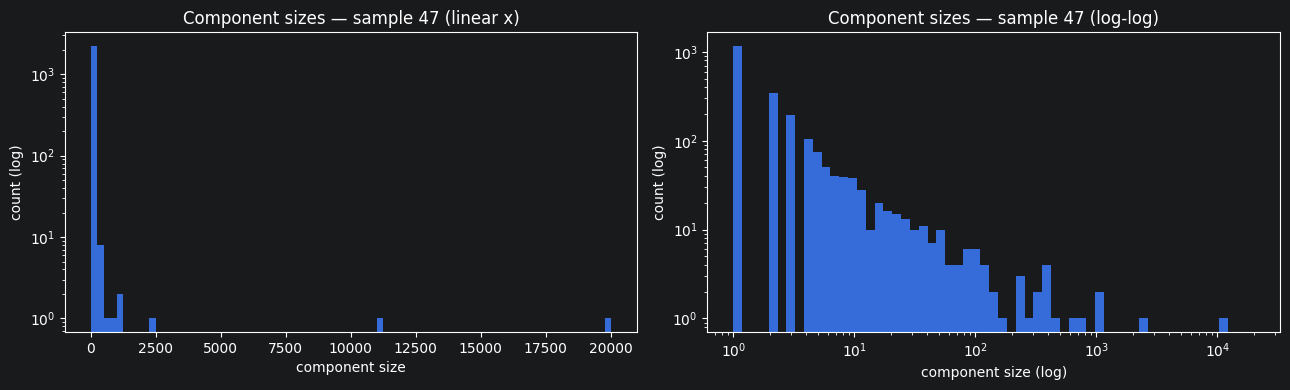

In [9]:
# Component-size distribution for sample 47.

comps = ig_graph.connected_components(mode="weak")
sizes = np.array(comps.sizes())
print(f"sample 47: {len(sizes):,} components in {ig_graph.vcount():,} nodes\n")

# Bucketed counts
buckets = [
    ("size == 1 (isolates)", (sizes == 1).sum(), int(sizes[sizes == 1].sum())),
    ("size 2-10",            ((sizes >= 2) & (sizes <= 10)).sum(),
                              int(sizes[(sizes >= 2) & (sizes <= 10)].sum())),
    ("size 11-100",          ((sizes >= 11) & (sizes <= 100)).sum(),
                              int(sizes[(sizes >= 11) & (sizes <= 100)].sum())),
    ("size 101-1000",        ((sizes >= 101) & (sizes <= 1000)).sum(),
                              int(sizes[(sizes >= 101) & (sizes <= 1000)].sum())),
    ("size > 1000",          (sizes > 1000).sum(),
                              int(sizes[sizes > 1000].sum())),
]
print(f"{'bucket':<25s} {'n_comps':>10s} {'n_cells':>10s} {'%cells':>8s}")
print("-" * 56)
for name, n_comp, n_cells in buckets:
    pct = 100 * n_cells / ig_graph.vcount()
    print(f"{name:<25s} {n_comp:>10,} {n_cells:>10,} {pct:>7.2f}%")

# "Mass above threshold" view
print(f"\nfraction of cells in components of size >= K:")
for K in [2, 10, 50, 100, 500, 1000, 5000, 10000]:
    mass = int(sizes[sizes >= K].sum())
    print(f"  K = {K:>5,}: {mass:>7,} cells ({100*mass/ig_graph.vcount():.1f}%) "
          f"in {(sizes >= K).sum():,} components")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sizes, bins=80)
axes[0].set_yscale("log")
axes[0].set_xlabel("component size")
axes[0].set_ylabel("count (log)")
axes[0].set_title(f"Component sizes — sample 47 (linear x)")

axes[1].hist(sizes, bins=np.logspace(0, np.log10(sizes.max()), 60))
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("component size (log)")
axes[1].set_ylabel("count (log)")
axes[1].set_title("Component sizes — sample 47 (log-log)")
plt.tight_layout()
plt.show()

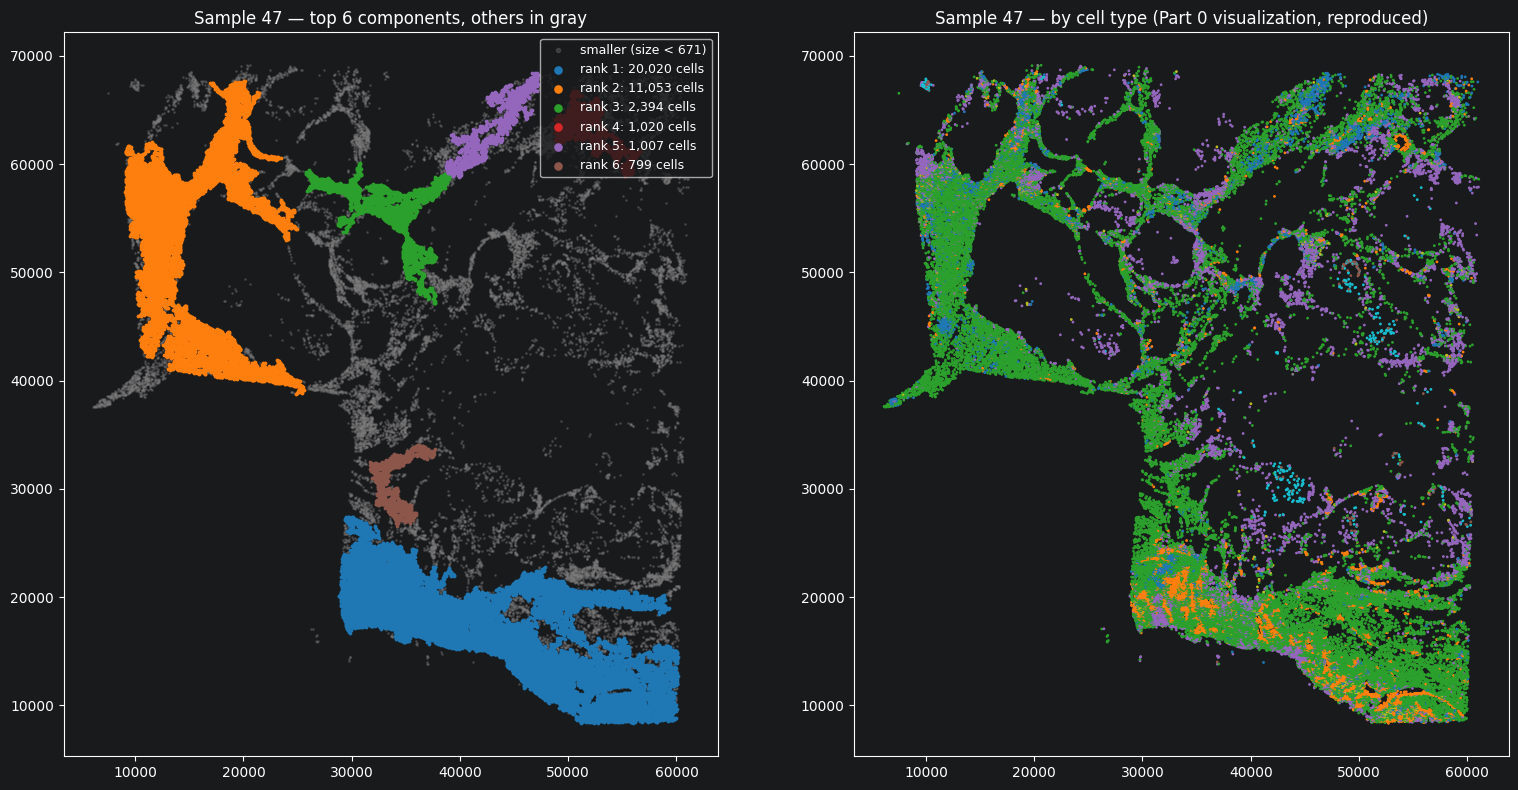

In [10]:
# Spatial visualization of components.
# Strategy: color by component size rank — biggest is one bright color,
# next few large ones distinct, everything smaller is gray.

# Per-node component membership
membership = np.array(comps.membership)        # (n_nodes,) component id per local node

# Get spatial positions for these nodes
pos_47 = G.positions[sg.global_idxs]            # (n_nodes, 2)

# Rank components by size, descending
size_per_comp = np.array(comps.sizes())
comp_rank = size_per_comp.argsort()[::-1]       # comp_rank[0] = largest component id
rank_lookup = np.full_like(size_per_comp, fill_value=-1)
rank_lookup[comp_rank] = np.arange(len(size_per_comp))
node_rank = rank_lookup[membership]             # rank of each node's component

# Assign colors: top-N get distinct, everything else gray
N_TOP = 6
top_colors = plt.cm.tab10.colors[:N_TOP]        # 6 distinct colors
gray = (0.5, 0.5, 0.5, 0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel A: spatial layout colored by top-N component membership
ax = axes[0]
# Draw "everything else" first as background
mask_other = node_rank >= N_TOP
ax.scatter(pos_47[mask_other, 0], pos_47[mask_other, 1],
           s=1, c=[gray], label=f"smaller (size < {size_per_comp[comp_rank[N_TOP]]})")
# Draw top-N on top, in order from largest to smallest so big one isn't covered
for r in range(N_TOP):
    mask = node_rank == r
    if mask.sum() == 0:
        continue
    cid = comp_rank[r]
    ax.scatter(pos_47[mask, 0], pos_47[mask, 1],
               s=3, c=[top_colors[r]],
               label=f"rank {r+1}: {size_per_comp[cid]:,} cells")
ax.set_aspect("equal")
ax.set_title(f"Sample 47 — top {N_TOP} components, others in gray")
ax.legend(loc="upper right", markerscale=3, fontsize=9)

# Panel B: cell-type layout for comparison (recovers the structure we saw in Part 0)
ax = axes[1]
ax.scatter(pos_47[:, 0], pos_47[:, 1], s=1, c=ct_47, cmap="tab10")
ax.set_aspect("equal")
ax.set_title("Sample 47 — by cell type (Part 0 visualization, reproduced)")

plt.tight_layout()
plt.show()

## 2. Cross-sample free-tier metrics

We compute the free-tier metrics for all 112 samples and save the table to `cache/topology/free_tier.parquet`. The table is the basis for every downstream comparison: distributions, patient groupings, correlations with composition.

Per-sample build + metric computation was ~0.1s for sample 47, so the full sweep should complete in well under a minute.

In [11]:
from tqdm.auto import tqdm

all_sample_ids = sorted(int(s) for s in np.unique(G.sample))

rows = []
t_start = time.time()
for s in tqdm(all_sample_ids, desc="topology"):
    sg_s = graph_construction.build_for_sample(s, global_arrays=G, weighted=False)
    ct_s = G.cell_type[sg_s.global_idxs]
    row = topology.compute_free_tier_metrics(sg_s, cell_type=ct_s)
    rows.append(row)

elapsed = time.time() - t_start
print(f"\ncomputed metrics for {len(rows)} samples in {elapsed:.1f}s "
      f"(avg {elapsed/len(rows):.2f}s per sample)")

free_tier = pd.DataFrame(rows).set_index("sample_id").sort_index()
print(f"\ntable shape: {free_tier.shape}")
print(free_tier.head())

/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
topology: 100%|██████████| 112/112 [00:39<00:00,  2.86it/s]


computed metrics for 112 samples in 39.1s (avg 0.35s per sample)

table shape: (112, 20)
           n_nodes  n_edges  mean_degree  median_degree  max_degree  \
sample_id                                                             
0            25863   109049     8.432819            9.0          16   
1           179133   701693     7.834324            8.0          18   
2            43023   191269     8.891477            9.0          16   
3           151919   606152     7.979937            8.0          17   
4            24838   107857     8.684838            9.0          16   

           degree_std  n_isolated  frac_isolated  n_components  \
sample_id                                                        
0            1.994725          61       0.002359           123   
1            2.361754         928       0.005181          1883   
2            1.366011          22       0.000511            48   
3            2.412141        1276       0.008399          2345   
4            1.7

In [12]:
# Persist the table.

topo_cache = Path(CACHE_DIR) / "topology"
topo_cache.mkdir(exist_ok=True, parents=True)
out_path = topo_cache / "free_tier.parquet"
free_tier.to_parquet(out_path)
print(f"saved to {out_path}")
print(f"file size: {out_path.stat().st_size / 1024:.1f} KB")

# Reload sanity-check
reloaded = pd.read_parquet(out_path)
assert (reloaded.values == free_tier.values).all() or \
       np.allclose(reloaded.select_dtypes('number').values,
                   free_tier.select_dtypes('number').values, equal_nan=True)
print("reload round-trips correctly")

saved to ../cache/topology/free_tier.parquet
file size: 27.3 KB
reload round-trips correctly


In [13]:
# First look: summary statistics across the 112 samples.
print("--- summary statistics across 112 samples ---")
print(free_tier.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(3))

--- summary statistics across 112 samples ---
                                 count        mean         std      min  \
n_nodes                          112.0   72013.938   60037.767  981.000   
n_edges                          112.0  282619.286  240443.861  777.000   
mean_degree                      112.0       7.895       1.142    1.584   
median_degree                    112.0       8.196       1.177    1.000   
max_degree                       112.0      15.768       0.986    9.000   
degree_std                       112.0       2.161       0.524    1.232   
n_isolated                       112.0     596.446     677.875    0.000   
frac_isolated                    112.0       0.012       0.031    0.000   
n_components                     112.0    1183.857    1345.087    4.000   
largest_component_size           112.0   56264.982   57975.612   53.000   
largest_component_frac           112.0       0.706       0.268    0.023   
n_components_excluding_isolates  112.0     587.411    

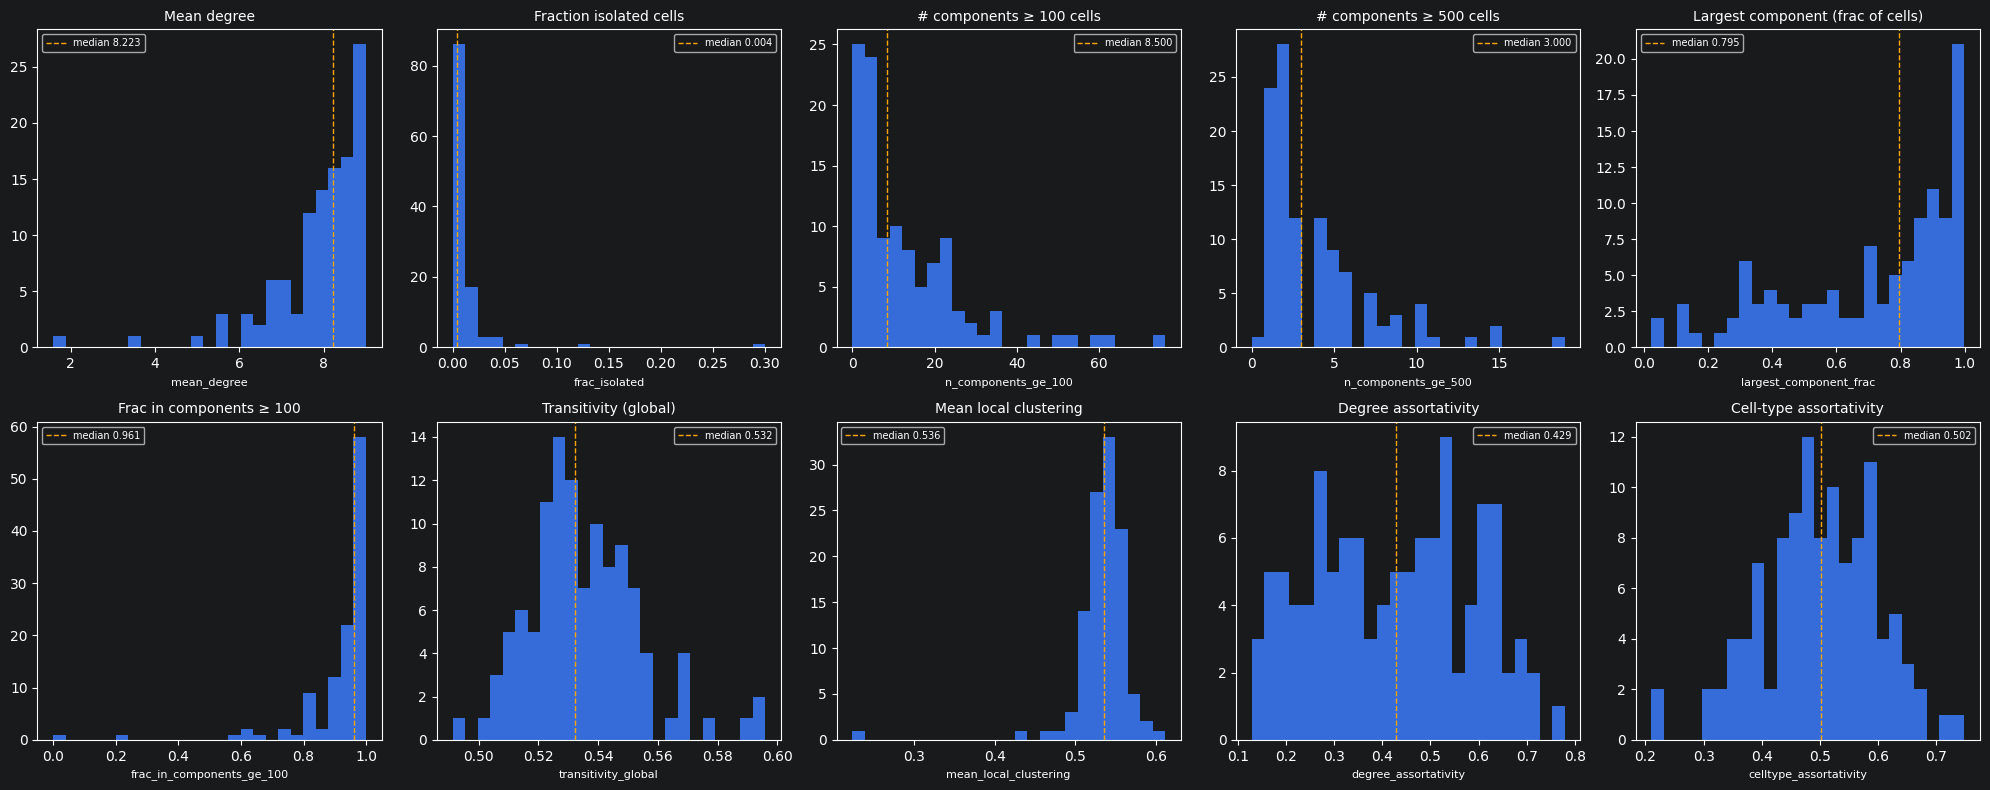

In [14]:
# Visualize the distributions of the most informative metrics across samples.
metrics_to_plot = [
    ("mean_degree",                 "Mean degree"),
    ("frac_isolated",               "Fraction isolated cells"),
    ("n_components_ge_100",         "# components ≥ 100 cells"),
    ("n_components_ge_500",         "# components ≥ 500 cells"),
    ("largest_component_frac",      "Largest component (frac of cells)"),
    ("frac_in_components_ge_100",   "Frac in components ≥ 100"),
    ("transitivity_global",         "Transitivity (global)"),
    ("mean_local_clustering",       "Mean local clustering"),
    ("degree_assortativity",        "Degree assortativity"),
    ("celltype_assortativity",      "Cell-type assortativity"),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    vals = free_tier[col].values
    ax.hist(vals, bins=25)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.axvline(np.median(vals), color="orange", linewidth=1, linestyle="--",
               label=f"median {np.median(vals):.3f}")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Is the bimodality of largest_component_frac real, or a size artifact?

The histogram showed two clear modes (~0.3-0.4 and ~0.95-1.0) for `largest_component_frac`. Before interpreting this as a biological/architectural finding, we should rule out that it just reflects small samples being more fragmented than large ones.

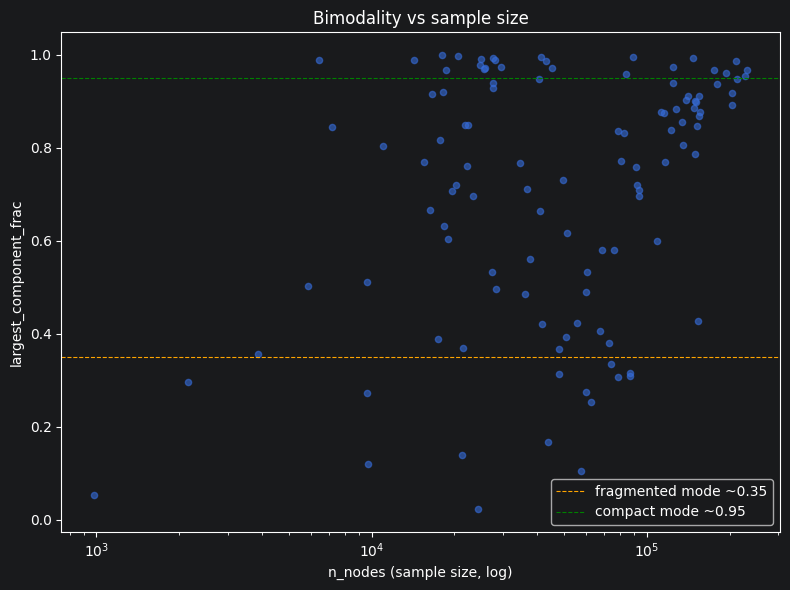

Spearman correlation (n_nodes vs largest_component_frac): 0.223
Pearson correlation:  0.340

small half (< median): n=56, fragmented (<0.5): 15, middle (0.5-0.9): 21, compact (>0.9): 20
large half (>= median): n=56, fragmented (<0.5): 13, middle (0.5-0.9): 26, compact (>0.9): 17


In [15]:
# Cell 21 implementation: size dependence

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(free_tier["n_nodes"], free_tier["largest_component_frac"],
           s=20, alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel("n_nodes (sample size, log)")
ax.set_ylabel("largest_component_frac")
ax.set_title("Bimodality vs sample size")
# Reference lines for the two modes
ax.axhline(0.35, color="orange", linestyle="--", linewidth=0.8, label="fragmented mode ~0.35")
ax.axhline(0.95, color="green", linestyle="--", linewidth=0.8, label="compact mode ~0.95")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Statistics
print(f"Spearman correlation (n_nodes vs largest_component_frac): "
      f"{free_tier[['n_nodes', 'largest_component_frac']].corr(method='spearman').iloc[0,1]:.3f}")
print(f"Pearson correlation:  "
      f"{free_tier[['n_nodes', 'largest_component_frac']].corr(method='pearson').iloc[0,1]:.3f}")
print()

# Split: are both modes present in both size halves?
median_size = free_tier["n_nodes"].median()
small = free_tier[free_tier["n_nodes"] < median_size]
large = free_tier[free_tier["n_nodes"] >= median_size]
for name, df in [("small half (< median)", small), ("large half (>= median)", large)]:
    fragmented = (df["largest_component_frac"] < 0.5).sum()
    compact    = (df["largest_component_frac"] > 0.9).sum()
    middle     = ((df["largest_component_frac"] >= 0.5) &
                  (df["largest_component_frac"] <= 0.9)).sum()
    print(f"{name}: n={len(df)}, fragmented (<0.5): {fragmented}, "
          f"middle (0.5-0.9): {middle}, compact (>0.9): {compact}")

## 4. Identifying anomalous samples

Define "anomalous" as a sample in the joint extreme tail: low mean degree AND low connectivity. These are samples where the spatial graph is essentially absent.

In [16]:
# Cell 22 implementation: identify anomalies

ANOMALY_CRITERIA = (
    (free_tier["mean_degree"] < 5.0) &
    (free_tier["largest_component_frac"] < 0.2)
)
anomalies = free_tier[ANOMALY_CRITERIA].copy()
print(f"samples meeting the anomaly criteria: {len(anomalies)}")
print()

if len(anomalies) > 0:
    cols_to_show = [
        "n_nodes", "n_edges", "mean_degree", "frac_isolated",
        "n_components", "largest_component_frac",
        "n_components_ge_100", "celltype_assortativity",
    ]
    print(anomalies[cols_to_show].round(3))
    print()

    # What patients do these belong to?
    sample_to_patient = pd.Series(
        G.patient[np.searchsorted(np.arange(G.n_cells),
                                  [np.where(G.sample == s)[0][0] for s in anomalies.index])],
        index=anomalies.index,
        name="patient",
    )
    # Cleaner: just look up the first cell of each sample
    sample_to_patient = pd.Series(
        {s: int(G.patient[G.sample == s][0]) for s in anomalies.index},
        name="patient",
    )
    print("anomaly samples by patient:")
    print(sample_to_patient.to_frame())

samples meeting the anomaly criteria: 2

           n_nodes  n_edges  mean_degree  frac_isolated  n_components  \
sample_id                                                               
87           24268    41530        3.423          0.127          5955   
107            981      777        1.584          0.301           437   

           largest_component_frac  n_components_ge_100  celltype_assortativity  
sample_id                                                                       
87                          0.023                   24                   0.603  
107                         0.054                    0                   0.338  

anomaly samples by patient:
     patient
87        47
107        7


## 5. Topology vs. biology

Three questions about whether topology metrics reflect biology vs. technical artifacts:

1. **Patient consistency:** the two samples of the same patient — do they have similar topology?
2. **Cell-type composition:** does composition predict topology metrics?
3. **Training mask:** is the mask's keep fraction related to topology (it should be, by construction)?

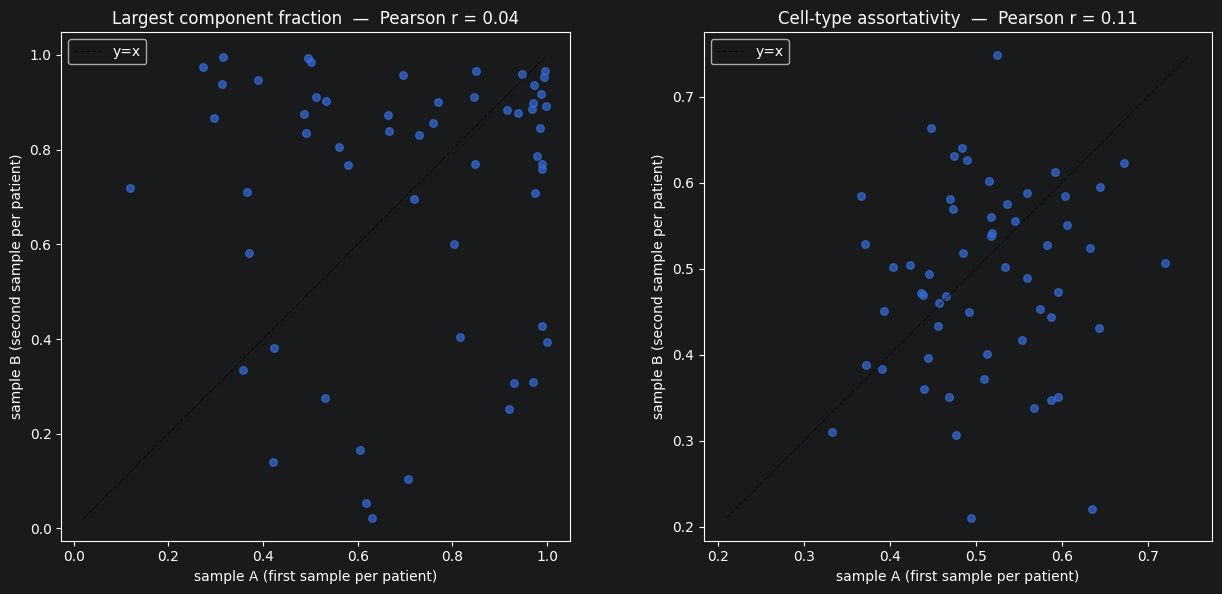

In [17]:
# Cell 23a: patient consistency

# Add patient info to the table
free_tier = free_tier.assign(
    patient=[int(G.patient[G.sample == s][0]) for s in free_tier.index],
)

# For each patient, get the two samples' largest_component_frac and celltype_assortativity
pair_rows = []
for p, sub in free_tier.groupby("patient"):
    if len(sub) == 2:
        s1, s2 = sub.index.tolist()
        pair_rows.append({
            "patient": p,
            "sample_A": s1,
            "sample_B": s2,
            "lcf_A": sub.loc[s1, "largest_component_frac"],
            "lcf_B": sub.loc[s2, "largest_component_frac"],
            "cta_A": sub.loc[s1, "celltype_assortativity"],
            "cta_B": sub.loc[s2, "celltype_assortativity"],
        })
pairs = pd.DataFrame(pair_rows)

# Plot sample_A vs sample_B for two key metrics
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (col_a, col_b, title) in zip(axes, [
    ("lcf_A", "lcf_B", "Largest component fraction"),
    ("cta_A", "cta_B", "Cell-type assortativity"),
]):
    ax.scatter(pairs[col_a], pairs[col_b], s=30, alpha=0.7)
    lim = [min(pairs[col_a].min(), pairs[col_b].min()),
           max(pairs[col_a].max(), pairs[col_b].max())]
    ax.plot(lim, lim, "k--", linewidth=0.8, alpha=0.5, label="y=x")
    ax.set_xlabel(f"sample A (first sample per patient)")
    ax.set_ylabel(f"sample B (second sample per patient)")
    r = pairs[[col_a, col_b]].corr(method="pearson").iloc[0, 1]
    ax.set_title(f"{title}  —  Pearson r = {r:.2f}")
    ax.set_aspect("equal")
    ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Cell 23b: composition correlation

# Compute composition per sample
comp_rows = []
for s in free_tier.index:
    mask = G.sample == s
    ct = G.cell_type[mask]
    counts = np.bincount(ct, minlength=8)
    comp_rows.append({**{f"frac_class_{i}": counts[i]/counts.sum() for i in range(8)},
                      "sample_id": int(s)})
composition = pd.DataFrame(comp_rows).set_index("sample_id")
free_tier_with_comp = free_tier.join(composition)

# Correlate composition columns with topology metrics
topo_cols = ["mean_degree", "frac_isolated", "largest_component_frac",
             "n_components_ge_100", "transitivity_global",
             "mean_local_clustering", "degree_assortativity",
             "celltype_assortativity"]
comp_cols = [f"frac_class_{i}" for i in range(8)]

corr = free_tier_with_comp[topo_cols + comp_cols].corr(method="spearman")
corr_block = corr.loc[topo_cols, comp_cols]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr_block.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(comp_cols)))
ax.set_xticklabels([c.replace("frac_class_", "class ") for c in comp_cols], rotation=0)
ax.set_yticks(range(len(topo_cols)))
ax.set_yticklabels(topo_cols)
for i in range(len(topo_cols)):
    for j in range(len(comp_cols)):
        v = corr_block.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax, label="Spearman ρ")
ax.set_title("Topology metrics × cell-type composition  (across 112 samples)")
plt.tight_layout()
plt.show()

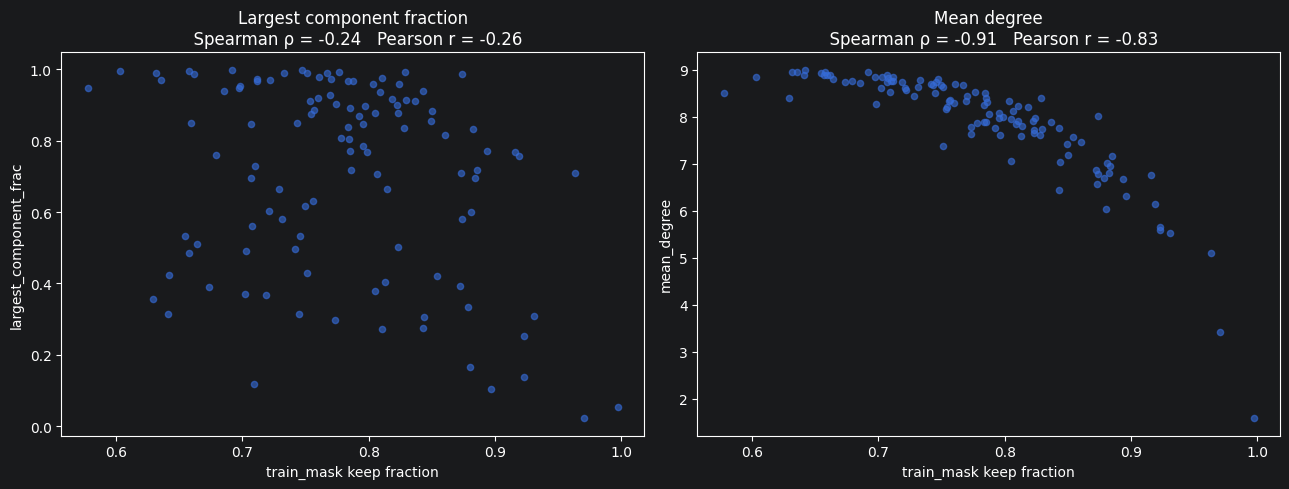

In [19]:
# Cell 23c: training-mask fraction correlation

mask_frac = pd.Series(
    {s: float(G.train_mask[G.sample == s].mean()) for s in free_tier.index},
    name="mask_frac"
)
free_tier_with_mask = free_tier.assign(mask_frac=mask_frac)

# Scatter of mask_frac vs the two key topology metrics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
                          ["largest_component_frac", "mean_degree"],
                          ["Largest component fraction", "Mean degree"]):
    ax.scatter(free_tier_with_mask["mask_frac"], free_tier_with_mask[col],
               s=20, alpha=0.6)
    ax.set_xlabel("train_mask keep fraction")
    ax.set_ylabel(col)
    r_s = free_tier_with_mask[["mask_frac", col]].corr(method="spearman").iloc[0,1]
    r_p = free_tier_with_mask[["mask_frac", col]].corr(method="pearson").iloc[0,1]
    ax.set_title(f"{title}\n  Spearman ρ = {r_s:.2f}   Pearson r = {r_p:.2f}")
plt.tight_layout()
plt.show()

## 6. Anomaly bookkeeping

Two samples (87, 107) meet the "broken topology" criterion. We flag them in the table and re-compute the cohort summaries with and without them to quantify their impact on cohort-level numbers.

In [20]:
# Add is_anomaly column based on the previously-defined criteria.
ANOMALY_IDS = [87, 107]
free_tier["is_anomaly"] = free_tier.index.isin(ANOMALY_IDS)
print(f"flagged samples: {free_tier.index[free_tier.is_anomaly].tolist()}")

# Persist updated table
free_tier.to_parquet(out_path)
print(f"updated table re-saved to {out_path}")

# Compare cohort summary with vs without anomalies on key metrics
key_metrics = [
    "mean_degree", "frac_isolated", "largest_component_frac",
    "n_components_ge_100", "frac_in_components_ge_100",
    "transitivity_global", "mean_local_clustering",
    "degree_assortativity", "celltype_assortativity",
]
with_all = free_tier[key_metrics].agg(["mean", "median", "std"]).T.add_suffix("_all")
without = free_tier[~free_tier.is_anomaly][key_metrics].agg(["mean", "median", "std"]).T.add_suffix("_clean")
comparison = pd.concat([with_all, without], axis=1).round(3)
# Reorder columns to interleave
comparison = comparison[["mean_all", "mean_clean",
                         "median_all", "median_clean",
                         "std_all", "std_clean"]]
print("\nCohort summary: all 112 vs 110 (anomalies removed)")
print(comparison)

flagged samples: [87, 107]
updated table re-saved to ../cache/topology/free_tier.parquet

Cohort summary: all 112 vs 110 (anomalies removed)
                           mean_all  mean_clean  median_all  median_clean  \
mean_degree                   7.895       7.993       8.223         8.241   
frac_isolated                 0.012       0.008       0.004         0.004   
largest_component_frac        0.706       0.718       0.795         0.805   
n_components_ge_100          13.438      13.464       8.500         8.500   
frac_in_components_ge_100     0.914       0.929       0.961         0.961   
transitivity_global           0.535       0.535       0.532         0.532   
mean_local_clustering         0.533       0.537       0.536         0.537   
degree_assortativity          0.424       0.419       0.429         0.420   
celltype_assortativity        0.499       0.499       0.502         0.502   

                           std_all  std_clean  
mean_degree                  1.142      

## 7. Expensive-tier metrics on a representative subset

Betweenness and closeness centrality are O(V·E) exactly; we use cutoff approximation and restrict to the giant connected component (where shortest paths are defined).

**Subset selection: 10 samples** stratified by architecture × size:
- 3 from the compact mode (lcf > 0.9)
- 3 from the bimodal middle (0.5 ≤ lcf ≤ 0.9)
- 3 from the fragmented mode (lcf < 0.5)
- Sample 87 as a sentinel for extreme fragmentation

In [21]:
# Pick 10 samples: 3 compact + 3 middle + 3 fragmented + sample 87.
# Within each bin, choose samples that span the size distribution.

rng_subset = np.random.default_rng(42)

def pick_three_spanning_size(df_bin, rng):
    """Pick small/medium/large within a bin."""
    df_sorted = df_bin.sort_values("n_nodes")
    n = len(df_sorted)
    if n < 3:
        return df_sorted.index.tolist()
    return [
        int(df_sorted.index[max(0, int(n * 0.2))]),     # small-ish
        int(df_sorted.index[int(n * 0.5)]),             # median
        int(df_sorted.index[min(n - 1, int(n * 0.8))]), # large-ish
    ]

clean = free_tier[~free_tier.is_anomaly]
compact     = pick_three_spanning_size(clean[clean.largest_component_frac > 0.9], rng_subset)
middle      = pick_three_spanning_size(clean[(clean.largest_component_frac >= 0.5) &
                                              (clean.largest_component_frac <= 0.9)], rng_subset)
fragmented  = pick_three_spanning_size(clean[clean.largest_component_frac < 0.5], rng_subset)
sentinel    = [87]

subset_ids = compact + middle + fragmented + sentinel
subset_bins = (["compact"] * 3 + ["middle"] * 3 + ["fragmented"] * 3 + ["sentinel"])
print(f"selected samples: {subset_ids}")
print()
print("subset details:")
display_cols = ["n_nodes", "largest_component_frac", "n_components_ge_100", "mean_degree"]
subset_view = free_tier.loc[subset_ids, display_cols].copy()
subset_view["bin"] = subset_bins
print(subset_view)

selected samples: [4, 2, 55, 88, 31, 23, 79, 47, 29, 87]

subset details:
           n_nodes  largest_component_frac  n_components_ge_100  mean_degree  \
sample_id                                                                      
4            24838                0.977937                    1     8.684838   
2            43023                0.986054                    2     8.891477   
55          175951                0.965968                    8     8.046274   
88           19513                0.706913                    6     8.124122   
31           68410                0.580705                   30     6.784301   
23          127954                0.883044                    6     7.193257   
79           21295                0.139375                   26     5.582155   
47           50988                0.392641                   29     6.861968   
29           72564                0.380133                   18     7.045918   
87           24268                0.022746    

In [22]:
# Compute expensive-tier metrics on the subset.
importlib.reload(topology)

expensive_results = []   # dicts with the per-node arrays
expensive_summary = []   # rows for the summary table

t_start = time.time()
for s, bin_label in zip(subset_ids, subset_bins):
    print(f"sample {s} ({bin_label}): n={int(free_tier.loc[s, 'n_nodes']):,}, "
          f"giant_frac={free_tier.loc[s, 'largest_component_frac']:.2f}", end=" ... ")
    t0 = time.time()
    sg_s = graph_construction.build_for_sample(s, global_arrays=G, weighted=False)
    ct_s = G.cell_type[sg_s.global_idxs]
    result = topology.compute_expensive_tier_metrics(sg_s, ct_s)
    elapsed = time.time() - t0
    print(f"done in {elapsed:.1f}s "
          f"(giant={result['giant_size']:,}, bw_max={result['betweenness_max']:.4f})")
    result["bin"] = bin_label
    expensive_results.append(result)
    expensive_summary.append({k: v for k, v in result.items() if not isinstance(v, np.ndarray)})

total = time.time() - t_start
print(f"\ntotal: {total/60:.1f} min for {len(subset_ids)} samples")

expensive_df = pd.DataFrame(expensive_summary).set_index("sample_id")
print()
print(expensive_df.round(5))

sample 4 (compact): n=24,838, giant_frac=0.98 ... done in 10.4s (giant=24,290, bw_max=10667033.3937)
sample 2 (compact): n=43,023, giant_frac=0.99 ... done in 32.8s (giant=42,423, bw_max=28801545.4284)
sample 55 (compact): n=175,951, giant_frac=0.97 ... done in 219.9s (giant=169,963, bw_max=49536827.1734)
sample 88 (middle): n=19,513, giant_frac=0.71 ... done in 3.2s (giant=13,794, bw_max=4726200.9172)
sample 31 (middle): n=68,410, giant_frac=0.58 ... done in 27.8s (giant=39,726, bw_max=25843660.9214)
sample 23 (middle): n=127,954, giant_frac=0.88 ... done in 112.9s (giant=112,989, bw_max=121657131.0397)
sample 79 (fragmented): n=21,295, giant_frac=0.14 ... done in 0.2s (giant=2,968, bw_max=107104.1526)
sample 47 (fragmented): n=50,988, giant_frac=0.39 ... done in 7.1s (giant=20,020, bw_max=4629131.7953)
sample 29 (fragmented): n=72,564, giant_frac=0.38 ... done in 12.4s (giant=27,584, bw_max=10813296.4822)
sample 87 (sentinel): n=24,268, giant_frac=0.02 ... done in 0.0s (giant=552, bw

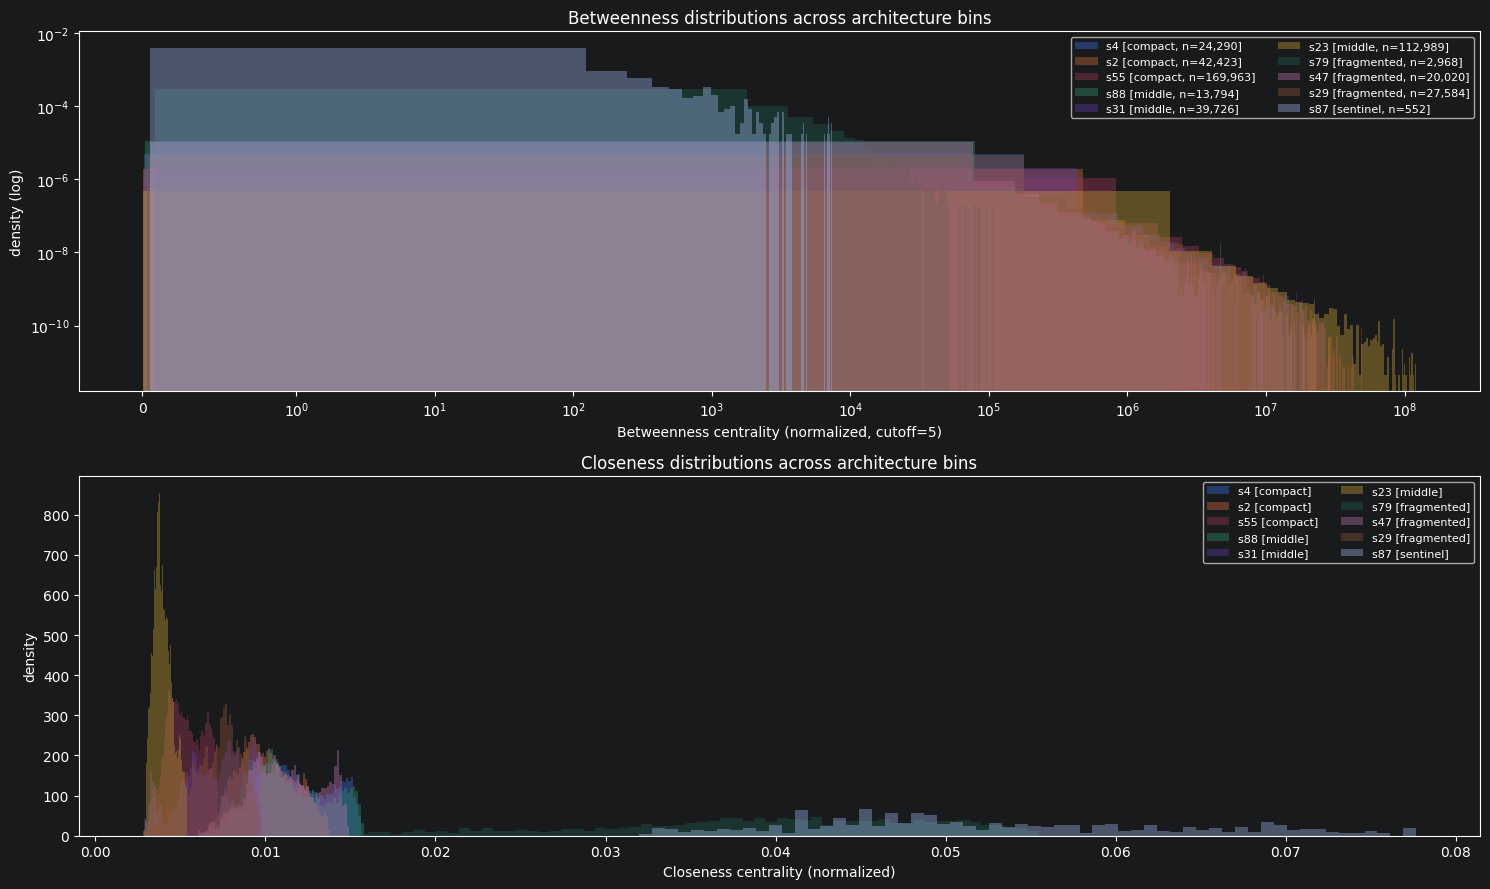

In [23]:
# Visualize centrality distributions across the 10 samples.

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Betweenness (log-scale on y to see the long tail)
ax = axes[0]
for r in expensive_results:
    vals = r["betweenness_per_node"]
    vals = vals[~np.isnan(vals)]
    vals = vals[vals > 0]  # drop zeros for log
    label = f"s{r['sample_id']} [{r['bin']}, n={r['giant_size']:,}]"
    ax.hist(vals, bins=60, alpha=0.4, label=label, density=True, log=True)
ax.set_xscale("symlog", linthresh=1.0)
ax.set_yscale("log")
ax.set_xlabel("Betweenness centrality (normalized, cutoff=5)")
ax.set_ylabel("density (log)")
ax.set_title("Betweenness distributions across architecture bins")
ax.legend(fontsize=8, ncol=2, loc="upper right")

# Closeness (linear)
ax = axes[1]
for r in expensive_results:
    vals = r["closeness_per_node"]
    vals = vals[~np.isnan(vals)]
    label = f"s{r['sample_id']} [{r['bin']}]"
    ax.hist(vals, bins=60, alpha=0.4, label=label, density=True)
ax.set_xlabel("Closeness centrality (normalized)")
ax.set_ylabel("density")
ax.set_title("Closeness distributions across architecture bins")
ax.legend(fontsize=8, ncol=2, loc="upper right")

plt.tight_layout()
plt.show()

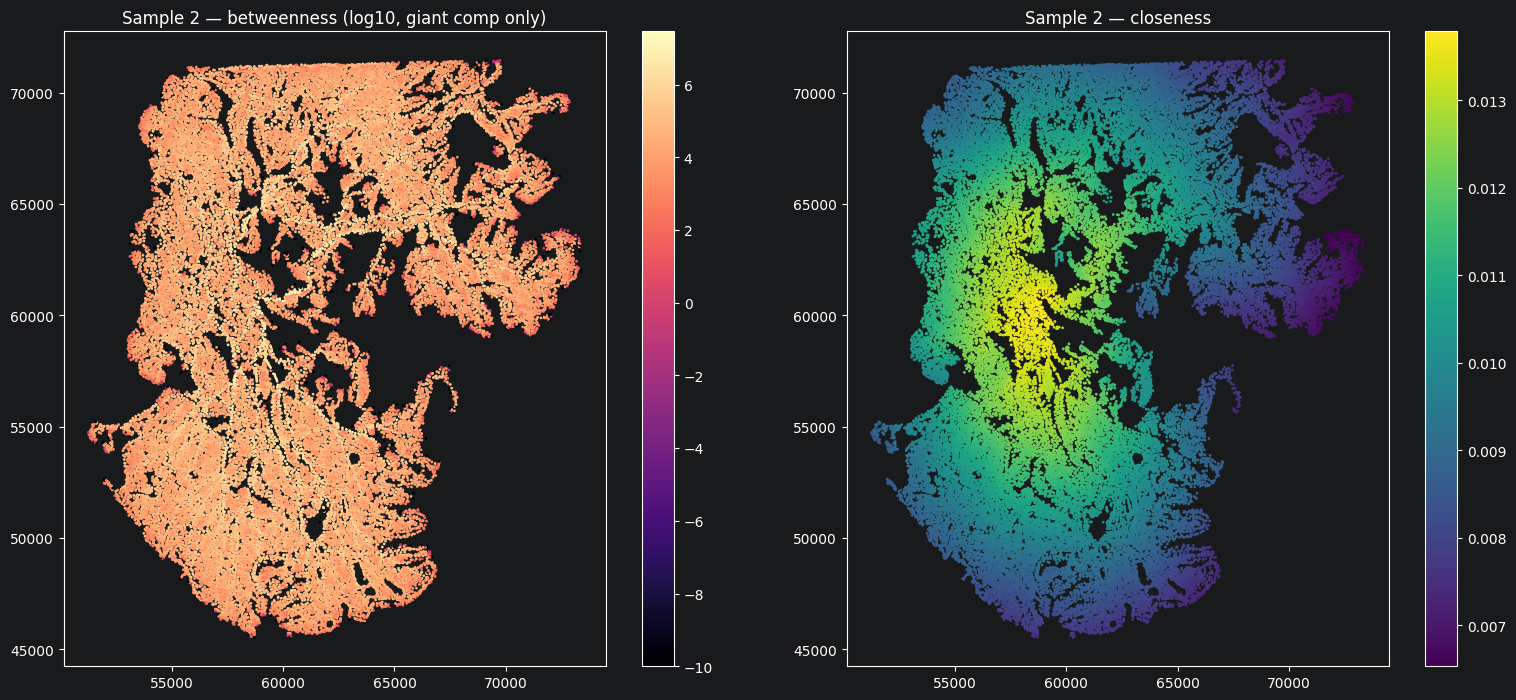

In [24]:
# One sample's centrality on the spatial layout — pick a compact sample.
# This visualizes whether high-centrality cells are spatially structured.

s_viz = compact[1]  # the median-sized compact sample
r_viz = next(r for r in expensive_results if r["sample_id"] == s_viz)
sg_viz = graph_construction.build_for_sample(s_viz, global_arrays=G, weighted=False)
pos = G.positions[sg_viz.global_idxs]

bw = r_viz["betweenness_per_node"]
cl = r_viz["closeness_per_node"]

# Only show giant-component cells
mask = ~np.isnan(bw)
pos_g = pos[mask]
bw_g  = bw[mask]
cl_g  = cl[mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Betweenness — log-scaled colors to highlight the few high ones
ax = axes[0]
sc = ax.scatter(pos_g[:, 0], pos_g[:, 1], s=1, c=np.log10(bw_g + 1e-10),
                cmap="magma")
ax.set_aspect("equal")
ax.set_title(f"Sample {s_viz} — betweenness (log10, giant comp only)")
plt.colorbar(sc, ax=ax)

ax = axes[1]
sc = ax.scatter(pos_g[:, 0], pos_g[:, 1], s=1, c=cl_g, cmap="viridis")
ax.set_aspect("equal")
ax.set_title(f"Sample {s_viz} — closeness")
plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

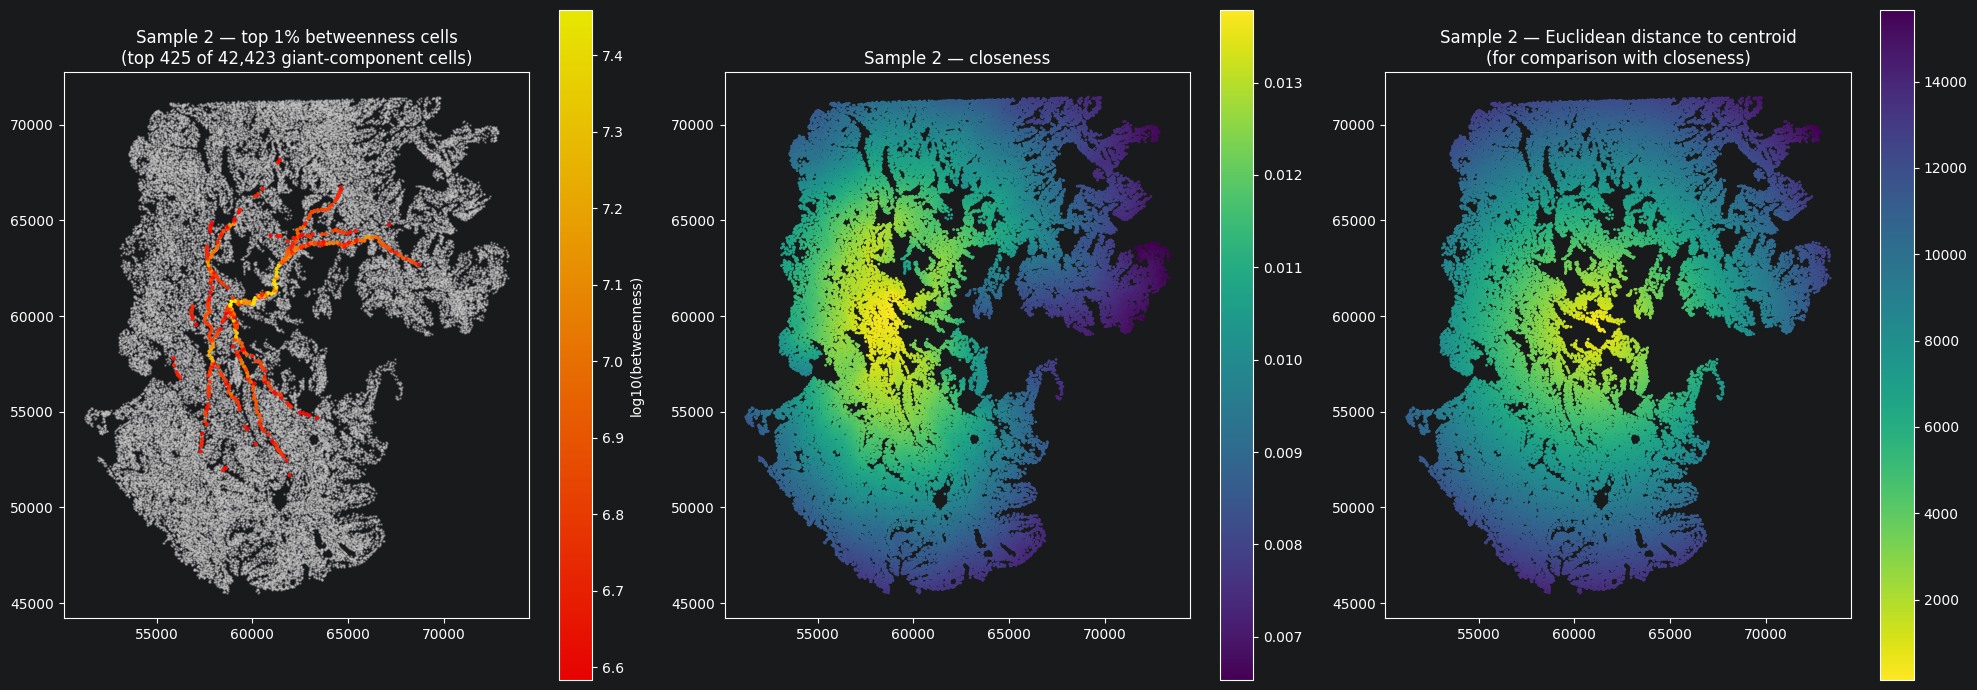

Correlation of closeness vs (negative) geometric distance to centroid: r = 0.805
(high positive r => closeness ≈ geometric centrality, not topological bottleneck info)


In [25]:
# Revised: clearer visualization of betweenness as "where the bottlenecks are."
# Approach: faint background of all giant-component cells, then highlight
# the top 1% by betweenness in bright orange.

# Compute distance-to-tissue-centroid for comparison
centroid_x = pos_g[:, 0].mean()
centroid_y = pos_g[:, 1].mean()
dist_to_centroid = np.sqrt((pos_g[:, 0] - centroid_x)**2 + (pos_g[:, 1] - centroid_y)**2)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1: top-1% betweenness highlighted
ax = axes[0]
threshold = np.percentile(bw_g, 99)
ax.scatter(pos_g[:, 0], pos_g[:, 1], s=0.5, c="lightgray", alpha=0.4)
mask_top = bw_g >= threshold
sc = ax.scatter(pos_g[mask_top, 0], pos_g[mask_top, 1],
                s=4, c=np.log10(bw_g[mask_top]),
                cmap="autumn", alpha=0.9)
ax.set_aspect("equal")
ax.set_title(f"Sample {s_viz} — top 1% betweenness cells\n"
             f"(top {mask_top.sum():,} of {len(bw_g):,} giant-component cells)")
plt.colorbar(sc, ax=ax, label="log10(betweenness)")

# Panel 2: closeness — but clipped to its meaningful range
ax = axes[1]
sc = ax.scatter(pos_g[:, 0], pos_g[:, 1], s=1, c=cl_g, cmap="viridis")
ax.set_aspect("equal")
ax.set_title(f"Sample {s_viz} — closeness")
plt.colorbar(sc, ax=ax)

# Panel 3: distance to centroid, for comparison with closeness
ax = axes[2]
sc = ax.scatter(pos_g[:, 0], pos_g[:, 1], s=1, c=dist_to_centroid, cmap="viridis_r")
ax.set_aspect("equal")
ax.set_title(f"Sample {s_viz} — Euclidean distance to centroid\n"
             "(for comparison with closeness)")
plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

# Quantify the closeness-vs-geometric correlation
r = np.corrcoef(cl_g, -dist_to_centroid)[0, 1]
print(f"Correlation of closeness vs (negative) geometric distance to centroid: r = {r:.3f}")
print("(high positive r => closeness ≈ geometric centrality, not topological bottleneck info)")

Sample 2: top-1% betweenness cells = 425
  rest of giant component                = 41,998

 class   bn_count   rest_count    bn_frac   rest_frac   log2_FC
-----------------------------------------------------------------
     0         39        8,514      0.092       0.203     -1.14
     1         94        8,081      0.221       0.192     +0.20
     2         33        4,158      0.078       0.099     -0.35
     3         43        3,491      0.101       0.083     +0.28
     4         91        8,974      0.214       0.214     +0.00
     5          1           53      0.002       0.001     +0.90
     6          4          488      0.009       0.012     -0.30
     7        120        8,239      0.282       0.196     +0.53


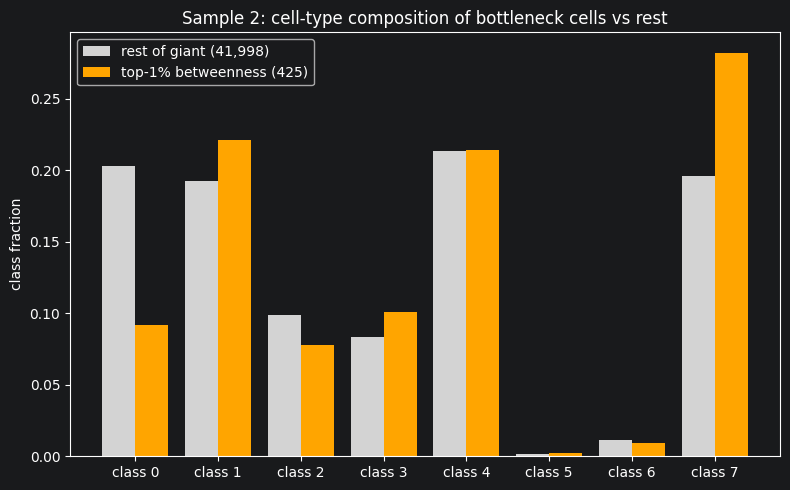

In [26]:
# Are the top-1% betweenness cells biased toward certain cell types?
# Compare class composition: bottleneck cells vs the rest of the giant component.

# We already have for sample 2: r_viz, sg_viz, pos_g, bw_g
# Need the cell types for the giant-component cells.
ct_viz_giant = G.cell_type[sg_viz.global_idxs][~np.isnan(bw)]  # giant cells only

threshold = np.percentile(bw_g, 99)
is_bottleneck = bw_g >= threshold

# Per-class proportions: bottleneck cells vs rest
n_classes = 8
counts_bottleneck = np.bincount(ct_viz_giant[is_bottleneck], minlength=n_classes)
counts_rest       = np.bincount(ct_viz_giant[~is_bottleneck], minlength=n_classes)
frac_bottleneck   = counts_bottleneck / counts_bottleneck.sum()
frac_rest         = counts_rest / counts_rest.sum()

# Log fold enrichment with pseudocount
eps = 1e-6
lfc = np.log2((frac_bottleneck + eps) / (frac_rest + eps))

print(f"Sample {s_viz}: top-1% betweenness cells = {is_bottleneck.sum():,}")
print(f"  rest of giant component                = {(~is_bottleneck).sum():,}")
print()
print(f"{'class':>6s} {'bn_count':>10s} {'rest_count':>12s} {'bn_frac':>10s} {'rest_frac':>11s} {'log2_FC':>9s}")
print("-" * 65)
for c in range(n_classes):
    print(f"{c:>6d} {counts_bottleneck[c]:>10,} {counts_rest[c]:>12,} "
          f"{frac_bottleneck[c]:>10.3f} {frac_rest[c]:>11.3f} {lfc[c]:>+9.2f}")

# Visual
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(n_classes)
ax.bar(x - 0.2, frac_rest, width=0.4, label=f"rest of giant ({(~is_bottleneck).sum():,})", color="lightgray")
ax.bar(x + 0.2, frac_bottleneck, width=0.4, label=f"top-1% betweenness ({is_bottleneck.sum():,})", color="orange")
ax.set_xticks(x)
ax.set_xticklabels([f"class {c}" for c in range(n_classes)])
ax.set_ylabel("class fraction")
ax.set_title(f"Sample {s_viz}: cell-type composition of bottleneck cells vs rest")
ax.legend()
plt.tight_layout()
plt.show()

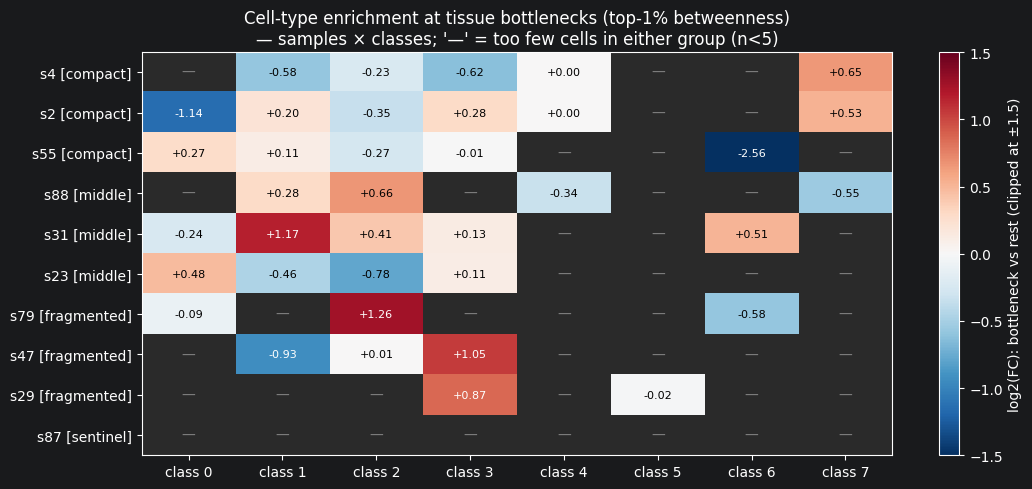


median log2 FC across samples (per class, after min-count filter):
  class 0: n_samples= 5  median = -0.09,  range = [-1.14, +0.48]
  class 1: n_samples= 7  median = +0.11,  range = [-0.93, +1.17]
  class 2: n_samples= 8  median = -0.11,  range = [-0.78, +1.26]
  class 3: n_samples= 7  median = +0.13,  range = [-0.62, +1.05]
  class 4: n_samples= 3  median = +0.00,  range = [-0.34, +0.00]
  class 5: n_samples= 1  median = -0.02,  range = [-0.02, -0.02]
  class 6: n_samples= 3  median = -0.58,  range = [-2.56, +0.51]
  class 7: n_samples= 3  median = +0.53,  range = [-0.55, +0.65]


In [28]:
# Revised: filter rare-class noise and cap the color scale to communicate
# the actual effect-size structure clearly.

MIN_COUNT_BOTH = 5    # require at least 5 cells in BOTH bottleneck and rest

n_classes = 8
lfc_matrix = np.full((len(expensive_results), n_classes), np.nan)
sample_ids_used = []
sample_bins = []

for i, r in enumerate(expensive_results):
    s = r["sample_id"]
    sample_ids_used.append(s)
    sample_bins.append(subset_bins[subset_ids.index(s)])

    sg_s = graph_construction.build_for_sample(s, global_arrays=G, weighted=False)
    ct_s = G.cell_type[sg_s.global_idxs]
    bw_full = r["betweenness_per_node"]
    giant_mask = ~np.isnan(bw_full)
    ct_giant = ct_s[giant_mask]
    bw_giant = bw_full[giant_mask]

    if giant_mask.sum() < 100:
        continue

    thresh = np.percentile(bw_giant, 99)
    is_bottleneck = bw_giant >= thresh
    cnt_bn = np.bincount(ct_giant[is_bottleneck].astype(int), minlength=n_classes)
    cnt_rest = np.bincount(ct_giant[~is_bottleneck].astype(int), minlength=n_classes)
    frac_bn = cnt_bn / cnt_bn.sum()
    frac_rest = cnt_rest / cnt_rest.sum()

    for c in range(n_classes):
        # Only compute LFC where both groups have a meaningful count.
        # Otherwise leave NaN (will display as blank).
        if cnt_bn[c] >= MIN_COUNT_BOTH and cnt_rest[c] >= MIN_COUNT_BOTH:
            lfc_matrix[i, c] = np.log2(frac_bn[c] / frac_rest[c])

# Heatmap, capped color scale, blank for filtered cells
fig, ax = plt.subplots(figsize=(11, 5))
VMAX = 1.5
masked = np.ma.masked_invalid(lfc_matrix)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="#2a2a2a")  # filtered cells -> dark gray
im = ax.imshow(masked, cmap=cmap, vmin=-VMAX, vmax=VMAX, aspect="auto")
ax.set_xticks(range(n_classes))
ax.set_xticklabels([f"class {c}" for c in range(n_classes)])
ax.set_yticks(range(len(sample_ids_used)))
ax.set_yticklabels([f"s{s} [{b}]" for s, b in zip(sample_ids_used, sample_bins)])
for i in range(len(sample_ids_used)):
    for j in range(n_classes):
        v = lfc_matrix[i, j]
        if np.isnan(v):
            ax.text(j, i, "—", ha="center", va="center", color="gray", fontsize=10)
        else:
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.8 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label=f"log2(FC): bottleneck vs rest (clipped at ±{VMAX})")
ax.set_title("Cell-type enrichment at tissue bottlenecks (top-1% betweenness)\n"
             f"— samples × classes; '—' = too few cells in either group (n<{MIN_COUNT_BOTH})")
plt.tight_layout()
plt.show()

# Summary: median log2 FC per class, ignoring NaN
print("\nmedian log2 FC across samples (per class, after min-count filter):")
for c in range(n_classes):
    col = lfc_matrix[:, c]
    col = col[~np.isnan(col)]
    if len(col) == 0:
        print(f"  class {c}: insufficient counts in all samples")
    else:
        print(f"  class {c}: n_samples={len(col):>2d}  "
              f"median = {np.median(col):+.2f},  range = [{col.min():+.2f}, {col.max():+.2f}]")

In [29]:
# Persist the expensive-tier per-sample summary table.
# We drop the per-node arrays (huge) and keep only the scalars.

expensive_summary_clean = pd.DataFrame([
    {k: v for k, v in r.items() if not isinstance(v, np.ndarray)}
    for r in expensive_results
]).set_index("sample_id")

# Add the bin label
expensive_summary_clean["bin"] = sample_bins

exp_path = topo_cache / "expensive_tier.parquet"
expensive_summary_clean.to_parquet(exp_path)
print(f"saved expensive-tier summary to {exp_path}")
print(f"  shape: {expensive_summary_clean.shape}")
print(f"  size:  {exp_path.stat().st_size / 1024:.1f} KB")
print()
print(expensive_summary_clean.round(4))

saved expensive-tier summary to ../cache/topology/expensive_tier.parquet
  shape: (10, 13)
  size:  10.2 KB

           giant_size  giant_frac  n_anchors_used  betweenness_max  \
sample_id                                                            
4               24290      0.9779            2429     1.066703e+07   
2               42423      0.9861            4242     2.880155e+07   
55             169963      0.9660            5000     4.953683e+07   
88              13794      0.7069            1379     4.726201e+06   
31              39726      0.5807            3972     2.584366e+07   
23             112989      0.8830            5000     1.216571e+08   
79               2968      0.1394             296     1.071042e+05   
47              20020      0.3926            2002     4.629132e+06   
29              27584      0.3801            2758     1.081330e+07   
87                552      0.0227              55     7.340335e+03   

           betweenness_p99  betweenness_p95  betwe

## 8. Summary of Part 1

### What we found

**The local topology of the spatial cell graph is consistent across the cohort.** Across 112 samples (after excluding 2 anomalies), transitivity, mean local clustering, and degree-related metrics show tight standard deviations (std < 5% of the mean). The same Visium HD + KNN-with-radius-cap preprocessing produces topologically-similar local microstructure on every section.

**Global connectivity is bimodal: tissue is either compact or fragmented.** The largest-connected-component fraction has two clear modes across the cohort (~35% and ~95%) plus a continuum between. This bimodality is *not* an artifact of sample size (size–connectivity Spearman ρ = 0.22) — both compact and fragmented sections exist at all sizes. It reflects genuine differences in tissue architecture: some sections are one big connected mass; others are multiple disconnected tissue islands.

**Topology is not consistent within patients.** The two sections per patient are topologically uncorrelated (largest-component-fraction Pearson r = 0.04, cell-type assortativity r = 0.11). Section-level variation dominates over patient-level biology in the spatial graph. This justifies the patient-level CV in DESIGN.md.

**Cell-type composition predicts topology.** Spearman correlations across 112 samples show that the fraction of class 5 cells in a sample strongly predicts sparser, more fragmented graphs (ρ for mean degree = −0.58, for n_components_ge_100 = +0.61). Class 0 and class 7 show opposing patterns: class 0 in sparser tissue regions, class 7 in denser ones. Classes 1, 2, 3 are flat — abundance-proportional.

**The training mask is essentially a function of mean degree.** Spearman ρ between train-mask keep fraction and mean degree is −0.91. This precisely confirms our Part 0 interpretation: the mask thins more aggressively where the spatial graph is denser, producing approximately uniform training-point density across samples.

**Centrality on planar spatial graphs is dominated by geometry.** Closeness centrality within a sample's giant component correlates r = 0.81 with simple Euclidean distance to the tissue centroid — it captures "where is the middle of the tissue" more than "where are network hubs." Betweenness centrality is more informative: top-1% betweenness cells form a sparse, branching skeleton along tissue narrowings (visible in sample 2 as a clean structural backbone). The bottleneck cells are *not* cell-type-specific: no class shows consistent enrichment across the 10 expensive-tier samples (median |log2 FC| < 0.15 for all classes with sufficient counts). Tissue bottlenecks are an architectural feature, not a biological niche.

### Anomalies flagged

- **Sample 87** (patient 47, 24k cells): mean degree 3.4, giant component 2.3%. A normal-sized section whose spatial graph is essentially absent — likely tissue damage or unusual cell dispersion.
- **Sample 107** (patient 7, 981 cells): the tiny section, fragmented as expected for its size.

Both are kept in the free-tier table with `is_anomaly=True`, excluded from cohort-level standard deviation summaries.

### What this means for downstream parts

- **Part 2 (niches):** Leiden community detection should be applied **within giant components** to avoid mistaking tissue islands for distinct niches. Cross-component "communities" are just tissue gaps.
- **Part 3 (GNN):** the 66k isolated cells and small-component cells should be handled deliberately — their representations will be local-only. Performance breakdown by component-size class is informative.
- **Part 5 (multi-layer):** the spatial layer is well-characterized and ready to combine with the gene-network layer.

### Methodological notes

- All analyses used the *unweighted* graph (edges treated as binary). A weighted version using `1 - mean(neighbor_radius)` was considered but not run; the unweighted analysis is the standard pedagogical fit for Lesson 10.1 and the conclusions above are sufficiently strong without weighting.
- Expensive-tier centralities use Brandes-Pich source/target sampling (5,000 anchors or 10% of giant size, whichever smaller). No path cutoff applied. Cross-sample magnitudes are not directly comparable; rankings within sample are stable.